In [16]:
import DBD_1
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [5]:
diesel_df = DBD_1.load_diesel()
petrol_df = DBD_1.load_petrol()
diesel_df

/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/notebooks/DBD_1.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/notebooks/DBD_1.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


,Date,Total_Fuel_Price,BFP,USDZAR_Mean,USDZAR_Std,USDZAR_LastWeekMean,Brent_MonthMean,Brent_MonthStd,Brent_LastWeekMean,Brent_LastWeekStd,...,GSCPI_Lag12,GECON_Lag1,GECON_Lag2,GECON_Lag3,INDPRO_Lag1,INDPRO_Lag2,INDPRO_Lag3,INDPRO_Lag6,INDPRO_Lag12,Total_Production
0,2011-01-01,789.451,477.03,6.905624,0.159159,7.088029,96.523500,1.432121,96.987143,0.932393,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68537.7764
1,2011-02-01,821.451,509.03,7.140163,0.118266,7.115057,101.449655,4.976158,109.406667,4.277731,...,NaN,0.247128,NaN,NaN,93.4814,NaN,NaN,NaN,NaN,68700.0099
2,2011-03-01,884.451,572.03,6.967600,0.120730,6.867400,113.560000,3.168441,115.761429,0.556729,...,NaN,0.423471,0.247128,NaN,93.1102,93.4814,NaN,NaN,NaN,67169.5421
3,2011-04-01,953.851,616.03,6.805250,0.119489,6.745443,120.723704,4.066770,124.930000,1.233450,...,NaN,-0.558572,0.423471,0.247128,94.0788,93.1102,93.4814,NaN,NaN,67351.0479
4,2011-05-01,969.851,632.03,6.828940,0.132094,6.962600,116.875000,5.568645,114.035000,2.422369,...,NaN,-0.258231,-0.558572,0.423471,93.7749,94.0788,93.1102,NaN,NaN,67087.4645
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,2026-03-01,1860.230,991.03,16.541643,0.435134,17.059043,94.781333,18.498657,114.968571,8.482695,...,-0.186074,0.209266,0.459790,0.464379,101.9263,101.0388,101.4941,101.6680,101.0404,42546.3814
183,2026-04-01,2611.230,2017.03,16.693410,0.273741,16.561714,116.748214,8.429096,116.922857,5.273420,...,-0.239936,-1.291190,0.209266,0.459790,101.6172,101.9263,101.0388,101.2195,101.1279,41147.4269
184,2026-05-01,3230.000,2606.10,16.490773,0.136545,16.379743,109.416071,7.794438,100.158333,5.808530,...,0.290260,-0.079102,-1.291190,0.209266,102.4196,101.6172,101.9263,101.0344,100.9655,34917.4440
185,2026-06-01,2875.970,2021.03,16.410380,0.134329,16.488629,89.264138,12.195101,72.888571,2.490324,...,0.096047,-0.001306,-0.079102,-1.291190,102.5606,102.4196,101.6172,101.4941,101.4785,NaN


## 1 Month Horizon

In [7]:
diesel_df['TFP-1M'] = diesel_df['Total_Fuel_Price'].shift(-1)
# Move 'TFP-1M' next to 'Date'
cols = ['Date', 'TFP-1M'] + [col for col in diesel_df.columns if col not in ['Date', 'TFP-1M']]
diesel_df_1M = diesel_df[cols]

# Display the new dataframe
diesel_df_1M.head()

,Date,TFP-1M,Total_Fuel_Price,BFP,USDZAR_Mean,USDZAR_Std,USDZAR_LastWeekMean,Brent_MonthMean,Brent_MonthStd,Brent_LastWeekMean,...,GSCPI_Lag12,GECON_Lag1,GECON_Lag2,GECON_Lag3,INDPRO_Lag1,INDPRO_Lag2,INDPRO_Lag3,INDPRO_Lag6,INDPRO_Lag12,Total_Production
0,2011-01-01,821.451,789.451,477.03,6.905624,0.159159,7.088029,96.523500,1.432121,96.987143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68537.7764
1,2011-02-01,884.451,821.451,509.03,7.140163,0.118266,7.115057,101.449655,4.976158,109.406667,...,NaN,0.247128,NaN,NaN,93.4814,NaN,NaN,NaN,NaN,68700.0099
2,2011-03-01,953.851,884.451,572.03,6.967600,0.120730,6.867400,113.560000,3.168441,115.761429,...,NaN,0.423471,0.247128,NaN,93.1102,93.4814,NaN,NaN,NaN,67169.5421
3,2011-04-01,969.851,953.851,616.03,6.805250,0.119489,6.745443,120.723704,4.066770,124.930000,...,NaN,-0.558572,0.423471,0.247128,94.0788,93.1102,93.4814,NaN,NaN,67351.0479
4,2011-05-01,932.851,969.851,632.03,6.828940,0.132094,6.962600,116.875000,5.568645,114.035000,...,NaN,-0.258231,-0.558572,0.423471,93.7749,94.0788,93.1102,NaN,NaN,67087.4645


In [8]:
petrol_df['TFP-1M'] = petrol_df['Total_Fuel_Price'].shift(-1)
# Move 'TFP-1M' next to 'Date'
cols = ['Date', 'TFP-1M'] + [col for col in petrol_df.columns if col not in ['Date', 'TFP-1M']]
petrol_df_1M = petrol_df[cols]

# Display the new dataframe
petrol_df_1M.head()

,Date,TFP-1M,Total_Fuel_Price,BFP,USDZAR_Mean,USDZAR_Std,USDZAR_LastWeekMean,Brent_MonthMean,Brent_MonthStd,Brent_LastWeekMean,...,GSCPI_Lag12,GECON_Lag1,GECON_Lag2,GECON_Lag3,INDPRO_Lag1,INDPRO_Lag2,INDPRO_Lag3,INDPRO_Lag6,INDPRO_Lag12,Total_Production
0,2011-01-01,898.8,872.8,453.949,6.905624,0.159159,7.088029,96.523500,1.432121,96.987143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68537.7764
1,2011-02-01,941.8,898.8,479.949,7.140163,0.118266,7.115057,101.449655,4.976158,109.406667,...,NaN,0.247128,NaN,NaN,93.4814,NaN,NaN,NaN,NaN,68700.0099
2,2011-03-01,996.4,941.8,522.949,6.967600,0.120730,6.867400,113.560000,3.168441,115.761429,...,NaN,0.423471,0.247128,NaN,93.1102,93.4814,NaN,NaN,NaN,67169.5421
3,2011-04-01,1025.4,996.4,552.149,6.805250,0.119489,6.745443,120.723704,4.066770,124.930000,...,NaN,-0.558572,0.423471,0.247128,94.0788,93.1102,93.4814,NaN,NaN,67351.0479
4,2011-05-01,1023.4,1025.4,581.149,6.828940,0.132094,6.962600,116.875000,5.568645,114.035000,...,NaN,-0.258231,-0.558572,0.423471,93.7749,94.0788,93.1102,NaN,NaN,67087.4645


In [14]:
corr_petrol = petrol_df_1M.corr(numeric_only=True)["TFP-1M"].sort_values(ascending=False)
corr_diesel = diesel_df_1M.corr(numeric_only=True)["TFP-1M"].sort_values(ascending=False)

print("\nHighest Correlations for Petrol (1M):")
print("=" * 40)
print(corr_petrol.head(10).to_string())
print("\nLowest Correlations for Petrol:")
print("=" * 40)
print(corr_petrol.tail(5).to_string())    



Highest Correlations for Petrol (1M):
TFP-1M                      1.000000
Total_Fuel_Price            0.984874
BFP                         0.900064
BFP_Lag1                    0.857644
BFP_Lag2                    0.822322
USDZAR_LastWeekMean         0.805851
USDZAR_Mean                 0.804844
BFP_Lag3                    0.799630
USDZAR_LastWeekMean_Lag1    0.798525
USDZAR_Mean_Lag1            0.797915

Lowest Correlations for Petrol:
GECON_Lag2          -0.020375
GECON_Lag3          -0.029008
USDZAR_Delta_Lag1   -0.033552
USDZAR_Delta_Lag2   -0.047667
Total_Production    -0.788079


In [15]:
print("\nHighest Correlations for Diesel (1M):")
print("=" * 40)
print(corr_diesel.head(10).to_string())
print("\nLowest Correlations for Diesel:")
print("=" * 40)
print(corr_diesel.tail(5).to_string())   


Highest Correlations for Diesel (1M):
TFP-1M                      1.000000
Total_Fuel_Price            0.972391
BFP                         0.914272
BFP_Lag1                    0.846553
BFP_Lag2                    0.816426
BFP_Lag3                    0.798845
BFP_Lag6                    0.751104
USDZAR_LastWeekMean         0.733183
USDZAR_Mean                 0.729922
USDZAR_LastWeekMean_Lag1    0.722224

Lowest Correlations for Diesel:
GECON_Lag1         -0.039507
GECON              -0.039571
GECON_Lag2         -0.041347
GECON_Lag3         -0.054300
Total_Production   -0.742614


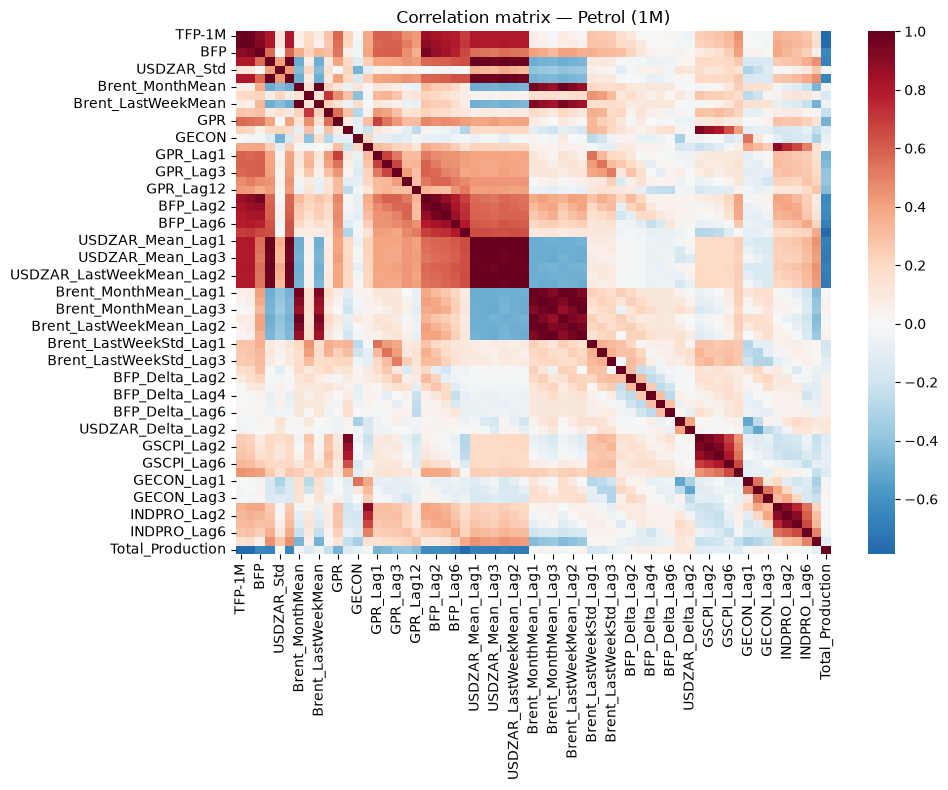

In [17]:
# --- Correlation heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(petrol_df_1M.corr(numeric_only=True), cmap="RdBu_r", center=0)
plt.title("Correlation matrix — Petrol (1M)")
plt.tight_layout()
plt.show()

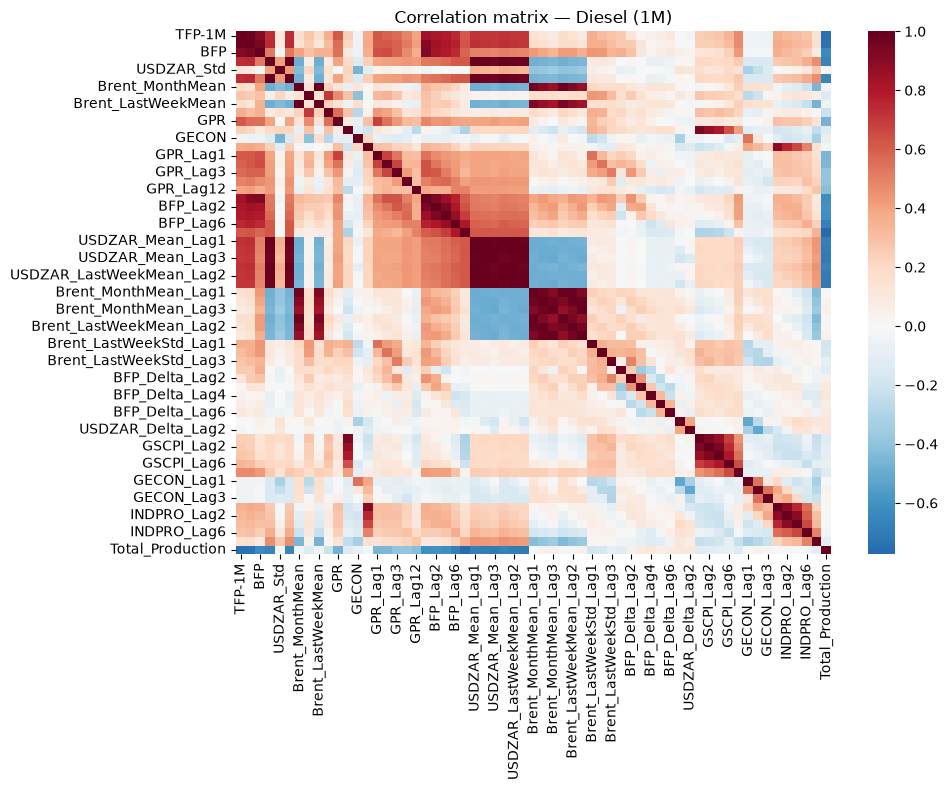

In [18]:
# --- Correlation heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(diesel_df_1M.corr(numeric_only=True), cmap="RdBu_r", center=0)
plt.title("Correlation matrix — Diesel (1M)")
plt.tight_layout()
plt.show()

## 2 Month Horizon

In [19]:
diesel_df['TFP-2M'] = diesel_df['Total_Fuel_Price'].shift(-2)
# Move 'TFP-2M' next to 'Date'
cols = ['Date', 'TFP-2M'] + [col for col in diesel_df.columns if col not in ['Date', 'TFP-2M', 'TFP-1M']]
diesel_df_2M = diesel_df[cols]

# Display the new dataframe
diesel_df_2M.head()

,Date,TFP-2M,Total_Fuel_Price,BFP,USDZAR_Mean,USDZAR_Std,USDZAR_LastWeekMean,Brent_MonthMean,Brent_MonthStd,Brent_LastWeekMean,...,GSCPI_Lag12,GECON_Lag1,GECON_Lag2,GECON_Lag3,INDPRO_Lag1,INDPRO_Lag2,INDPRO_Lag3,INDPRO_Lag6,INDPRO_Lag12,Total_Production
0,2011-01-01,884.451,789.451,477.03,6.905624,0.159159,7.088029,96.523500,1.432121,96.987143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68537.7764
1,2011-02-01,953.851,821.451,509.03,7.140163,0.118266,7.115057,101.449655,4.976158,109.406667,...,NaN,0.247128,NaN,NaN,93.4814,NaN,NaN,NaN,NaN,68700.0099
2,2011-03-01,969.851,884.451,572.03,6.967600,0.120730,6.867400,113.560000,3.168441,115.761429,...,NaN,0.423471,0.247128,NaN,93.1102,93.4814,NaN,NaN,NaN,67169.5421
3,2011-04-01,932.851,953.851,616.03,6.805250,0.119489,6.745443,120.723704,4.066770,124.930000,...,NaN,-0.558572,0.423471,0.247128,94.0788,93.1102,93.4814,NaN,NaN,67351.0479
4,2011-05-01,920.851,969.851,632.03,6.828940,0.132094,6.962600,116.875000,5.568645,114.035000,...,NaN,-0.258231,-0.558572,0.423471,93.7749,94.0788,93.1102,NaN,NaN,67087.4645


In [21]:
petrol_df['TFP-2M'] = petrol_df['Total_Fuel_Price'].shift(-2)
# Move 'TFP-2M' next to 'Date'
cols = ['Date', 'TFP-2M'] + [col for col in petrol_df.columns if col not in ['Date', 'TFP-2M', 'TFP-1M']]
petrol_df_2M = petrol_df[cols]

# Display the new dataframe
petrol_df_2M.head()

,Date,TFP-2M,Total_Fuel_Price,BFP,USDZAR_Mean,USDZAR_Std,USDZAR_LastWeekMean,Brent_MonthMean,Brent_MonthStd,Brent_LastWeekMean,...,GSCPI_Lag12,GECON_Lag1,GECON_Lag2,GECON_Lag3,INDPRO_Lag1,INDPRO_Lag2,INDPRO_Lag3,INDPRO_Lag6,INDPRO_Lag12,Total_Production
0,2011-01-01,941.8,872.8,453.949,6.905624,0.159159,7.088029,96.523500,1.432121,96.987143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68537.7764
1,2011-02-01,996.4,898.8,479.949,7.140163,0.118266,7.115057,101.449655,4.976158,109.406667,...,NaN,0.247128,NaN,NaN,93.4814,NaN,NaN,NaN,NaN,68700.0099
2,2011-03-01,1025.4,941.8,522.949,6.967600,0.120730,6.867400,113.560000,3.168441,115.761429,...,NaN,0.423471,0.247128,NaN,93.1102,93.4814,NaN,NaN,NaN,67169.5421
3,2011-04-01,1023.4,996.4,552.149,6.805250,0.119489,6.745443,120.723704,4.066770,124.930000,...,NaN,-0.558572,0.423471,0.247128,94.0788,93.1102,93.4814,NaN,NaN,67351.0479
4,2011-05-01,992.4,1025.4,581.149,6.828940,0.132094,6.962600,116.875000,5.568645,114.035000,...,NaN,-0.258231,-0.558572,0.423471,93.7749,94.0788,93.1102,NaN,NaN,67087.4645


In [22]:
corr_petrol_2M = petrol_df_2M.corr(numeric_only=True)["TFP-2M"].sort_values(ascending=False)
corr_diesel_2M = diesel_df_2M.corr(numeric_only=True)["TFP-2M"].sort_values(ascending=False)

print("\nHighest Correlations for Petrol (2M):")
print("=" * 40)
print(corr_petrol_2M.head(10).to_string())
print("\nLowest Correlations for Petrol:")
print("=" * 40)
print(corr_petrol_2M.tail(5).to_string())



Highest Correlations for Petrol (2M):
TFP-2M                      1.000000
Total_Fuel_Price            0.959751
BFP                         0.857644
BFP_Lag1                    0.822322
BFP_Lag2                    0.799630
USDZAR_LastWeekMean         0.798525
USDZAR_Mean                 0.797915
BFP_Lag3                    0.792273
USDZAR_LastWeekMean_Lag1    0.792261
USDZAR_Mean_Lag1            0.791495

Lowest Correlations for Petrol:
Brent_MonthMean_Lag3   -0.027215
GECON_Lag2             -0.029008
USDZAR_Delta_Lag1      -0.047667
USDZAR_Delta_Lag2      -0.065105
Total_Production       -0.791419


In [23]:
print("\nHighest Correlations for Diesel (2M):")
print("=" * 40)
print(corr_diesel_2M.head(10).to_string())
print("\nLowest Correlations for Diesel:")
print("=" * 40)
print(corr_diesel_2M.tail(5).to_string())



Highest Correlations for Diesel (2M):
TFP-2M                      1.000000
Total_Fuel_Price            0.926891
BFP                         0.846553
BFP_Lag1                    0.816426
BFP_Lag2                    0.798845
BFP_Lag3                    0.790027
BFP_Lag6                    0.724330
USDZAR_LastWeekMean         0.722224
USDZAR_Mean                 0.719154
USDZAR_LastWeekMean_Lag1    0.710997

Lowest Correlations for Diesel:
GECON_Lag1          -0.041347
GECON_Lag3          -0.042499
GECON_Lag2          -0.054300
USDZAR_Delta_Lag2   -0.058976
Total_Production    -0.744728


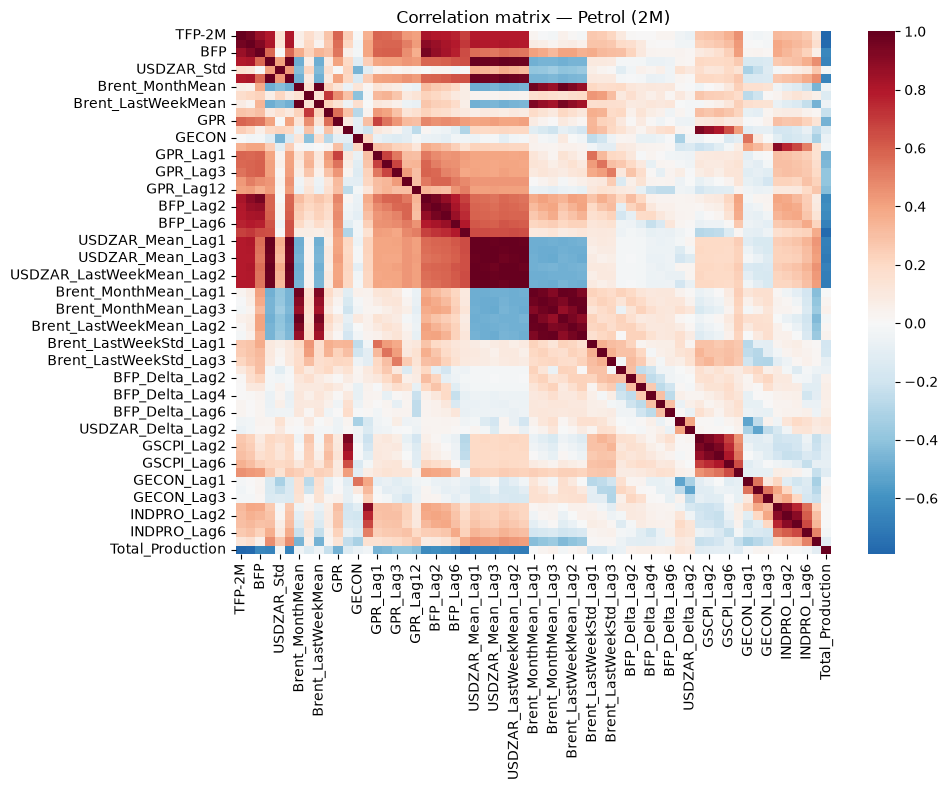

In [24]:
# --- Correlation heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(petrol_df_2M.corr(numeric_only=True), cmap="RdBu_r", center=0)
plt.title("Correlation matrix — Petrol (2M)")
plt.tight_layout()
plt.show()

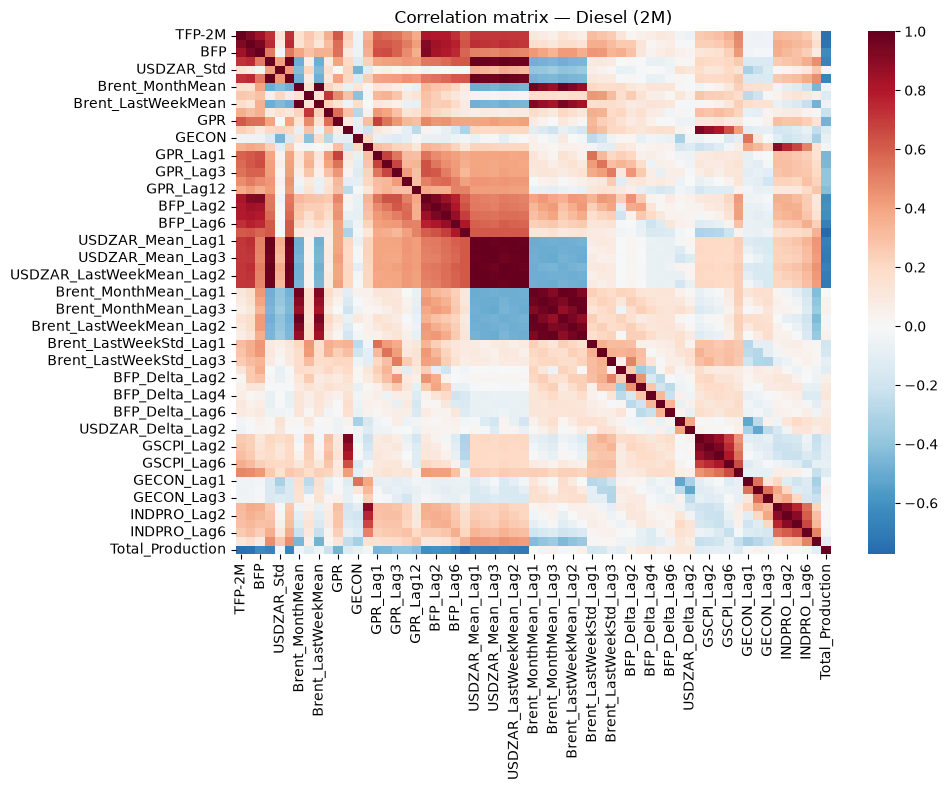

In [25]:
# --- Correlation heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(diesel_df_2M.corr(numeric_only=True), cmap="RdBu_r", center=0)
plt.title("Correlation matrix — Diesel (2M)")
plt.tight_layout()
plt.show()

## 3 Month Horizon

In [26]:
diesel_df_2M['TFP-3M'] = diesel_df_2M['Total_Fuel_Price'].shift(-3)
# Move 'TFP-2M' next to 'Date'
cols = ['Date', 'TFP-3M'] + [col for col in diesel_df_2M.columns if col not in ['Date', 'TFP-2M', 'TFP-3M']]
diesel_df_3M = diesel_df_2M[cols]

# Display the new dataframe
diesel_df_3M.head()

,Date,TFP-3M,Total_Fuel_Price,BFP,USDZAR_Mean,USDZAR_Std,USDZAR_LastWeekMean,Brent_MonthMean,Brent_MonthStd,Brent_LastWeekMean,...,GSCPI_Lag12,GECON_Lag1,GECON_Lag2,GECON_Lag3,INDPRO_Lag1,INDPRO_Lag2,INDPRO_Lag3,INDPRO_Lag6,INDPRO_Lag12,Total_Production
0,2011-01-01,953.851,789.451,477.03,6.905624,0.159159,7.088029,96.523500,1.432121,96.987143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68537.7764
1,2011-02-01,969.851,821.451,509.03,7.140163,0.118266,7.115057,101.449655,4.976158,109.406667,...,NaN,0.247128,NaN,NaN,93.4814,NaN,NaN,NaN,NaN,68700.0099
2,2011-03-01,932.851,884.451,572.03,6.967600,0.120730,6.867400,113.560000,3.168441,115.761429,...,NaN,0.423471,0.247128,NaN,93.1102,93.4814,NaN,NaN,NaN,67169.5421
3,2011-04-01,920.851,953.851,616.03,6.805250,0.119489,6.745443,120.723704,4.066770,124.930000,...,NaN,-0.558572,0.423471,0.247128,94.0788,93.1102,93.4814,NaN,NaN,67351.0479
4,2011-05-01,935.851,969.851,632.03,6.828940,0.132094,6.962600,116.875000,5.568645,114.035000,...,NaN,-0.258231,-0.558572,0.423471,93.7749,94.0788,93.1102,NaN,NaN,67087.4645


In [27]:
petrol_df_2M['TFP-3M'] = petrol_df_2M['Total_Fuel_Price'].shift(-3)
# Move 'TFP-2M' next to 'Date'
cols = ['Date', 'TFP-3M'] + [col for col in petrol_df_2M.columns if col not in ['Date', 'TFP-2M', 'TFP-3M']]
petrol_df_3M = petrol_df_2M[cols]

# Display the new dataframe
petrol_df_3M.head()

,Date,TFP-3M,Total_Fuel_Price,BFP,USDZAR_Mean,USDZAR_Std,USDZAR_LastWeekMean,Brent_MonthMean,Brent_MonthStd,Brent_LastWeekMean,...,GSCPI_Lag12,GECON_Lag1,GECON_Lag2,GECON_Lag3,INDPRO_Lag1,INDPRO_Lag2,INDPRO_Lag3,INDPRO_Lag6,INDPRO_Lag12,Total_Production
0,2011-01-01,996.4,872.8,453.949,6.905624,0.159159,7.088029,96.523500,1.432121,96.987143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68537.7764
1,2011-02-01,1025.4,898.8,479.949,7.140163,0.118266,7.115057,101.449655,4.976158,109.406667,...,NaN,0.247128,NaN,NaN,93.4814,NaN,NaN,NaN,NaN,68700.0099
2,2011-03-01,1023.4,941.8,522.949,6.967600,0.120730,6.867400,113.560000,3.168441,115.761429,...,NaN,0.423471,0.247128,NaN,93.1102,93.4814,NaN,NaN,NaN,67169.5421
3,2011-04-01,992.4,996.4,552.149,6.805250,0.119489,6.745443,120.723704,4.066770,124.930000,...,NaN,-0.558572,0.423471,0.247128,94.0788,93.1102,93.4814,NaN,NaN,67351.0479
4,2011-05-01,1009.4,1025.4,581.149,6.828940,0.132094,6.962600,116.875000,5.568645,114.035000,...,NaN,-0.258231,-0.558572,0.423471,93.7749,94.0788,93.1102,NaN,NaN,67087.4645


In [28]:
corr_petrol_3M = petrol_df_3M.corr(numeric_only=True)["TFP-3M"].sort_values(ascending=False)
corr_diesel_3M = diesel_df_3M.corr(numeric_only=True)["TFP-3M"].sort_values(ascending=False)

print("\nHighest Correlations for Petrol (3M):")
print("=" * 40)
print(corr_petrol_3M.head(10).to_string())
print("\nLowest Correlations for Petrol:")
print("=" * 40)
print(corr_petrol_3M.tail(5).to_string())


Highest Correlations for Petrol (3M):
TFP-3M                      1.000000
Total_Fuel_Price            0.941868
BFP                         0.822322
BFP_Lag1                    0.799630
BFP_Lag2                    0.792273
USDZAR_LastWeekMean         0.792261
USDZAR_Mean                 0.791495
USDZAR_Mean_Lag1            0.787329
USDZAR_LastWeekMean_Lag1    0.787257
BFP_Lag3                    0.786299

Lowest Correlations for Petrol:
GECON_Lag1             -0.029008
Brent_MonthMean_Lag3   -0.033350
USDZAR_Delta_Lag1      -0.065105
USDZAR_Delta_Lag2      -0.080223
Total_Production       -0.784120


In [29]:
print("\nHighest Correlations for Diesel (3M):")
print("=" * 40)
print(corr_diesel_3M.head(10).to_string())
print("\nLowest Correlations for Diesel:")
print("=" * 40)
print(corr_diesel_3M.tail(5).to_string())


Highest Correlations for Diesel (3M):
TFP-3M                      1.000000
Total_Fuel_Price            0.902313
BFP                         0.816426
BFP_Lag1                    0.798845
BFP_Lag2                    0.790027
BFP_Lag3                    0.773146
USDZAR_LastWeekMean         0.710997
USDZAR_Mean                 0.710073
USDZAR_Mean_Lag1            0.705744
USDZAR_LastWeekMean_Lag1    0.705031

Lowest Correlations for Diesel:
GECON_Lag2          -0.042499
GECON_Lag1          -0.054300
USDZAR_Delta_Lag1   -0.058976
USDZAR_Delta_Lag2   -0.063011
Total_Production    -0.735416


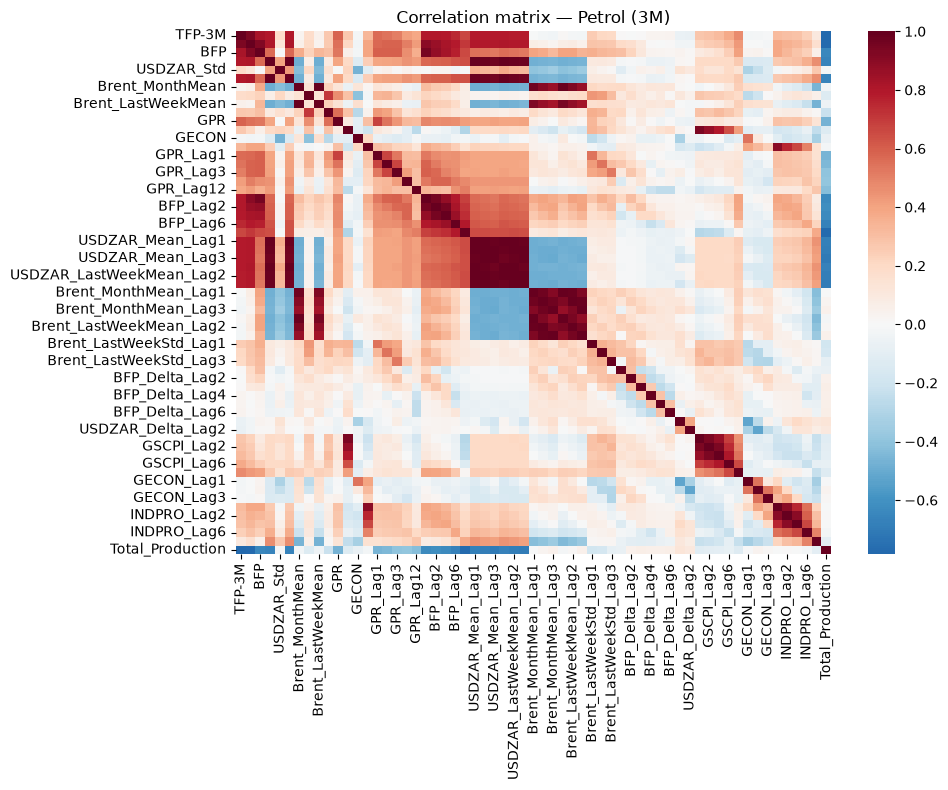

In [31]:
# --- Correlation heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(petrol_df_3M.corr(numeric_only=True), cmap="RdBu_r", center=0)
plt.title("Correlation matrix — Petrol (3M)")
plt.tight_layout()
plt.show()

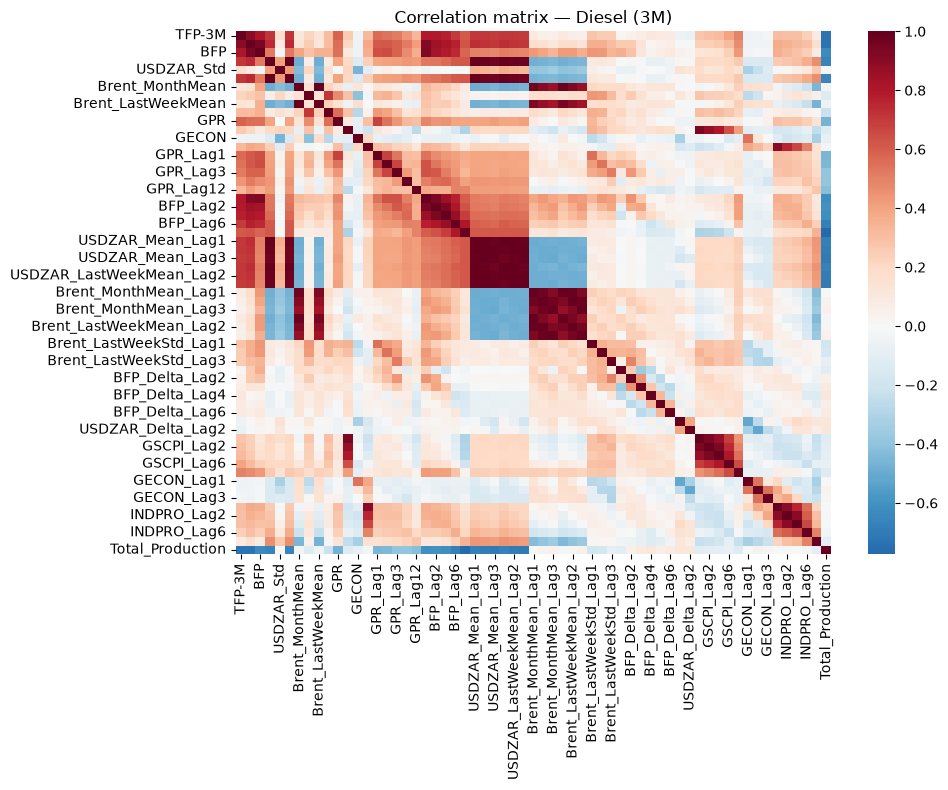

In [ ]:
# --- Correlation heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(diesel_df_3M.corr(numeric_only=True), cmap="RdBu_r", center=0)
plt.title("Correlation matrix — Diesel (3M)")
plt.tight_layout()
plt.show()

## 4 Month Horizon

In [40]:
petrol_df_3M['TFP-4M'] = petrol_df_3M['Total_Fuel_Price'].shift(-4)
# Move 'TFP-2M' next to 'Date'
cols = ['Date', 'TFP-4M'] + [col for col in petrol_df_3M.columns if col not in ['Date', 'TFP-3M', 'TFP-4M']]
petrol_df_4M = petrol_df_3M[cols]

# Display the new dataframe
petrol_df_4M.head()

,Date,TFP-4M,Total_Fuel_Price,BFP,USDZAR_Mean,USDZAR_Std,USDZAR_LastWeekMean,Brent_MonthMean,Brent_MonthStd,Brent_LastWeekMean,...,GSCPI_Lag12,GECON_Lag1,GECON_Lag2,GECON_Lag3,INDPRO_Lag1,INDPRO_Lag2,INDPRO_Lag3,INDPRO_Lag6,INDPRO_Lag12,Total_Production
0,2011-01-01,1025.4,872.8,453.949,6.905624,0.159159,7.088029,96.523500,1.432121,96.987143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68537.7764
1,2011-02-01,1023.4,898.8,479.949,7.140163,0.118266,7.115057,101.449655,4.976158,109.406667,...,NaN,0.247128,NaN,NaN,93.4814,NaN,NaN,NaN,NaN,68700.0099
2,2011-03-01,992.4,941.8,522.949,6.967600,0.120730,6.867400,113.560000,3.168441,115.761429,...,NaN,0.423471,0.247128,NaN,93.1102,93.4814,NaN,NaN,NaN,67169.5421
3,2011-04-01,1009.4,996.4,552.149,6.805250,0.119489,6.745443,120.723704,4.066770,124.930000,...,NaN,-0.558572,0.423471,0.247128,94.0788,93.1102,93.4814,NaN,NaN,67351.0479
4,2011-05-01,1018.4,1025.4,581.149,6.828940,0.132094,6.962600,116.875000,5.568645,114.035000,...,NaN,-0.258231,-0.558572,0.423471,93.7749,94.0788,93.1102,NaN,NaN,67087.4645


In [51]:
diesel_df_3M['TFP-4M'] = diesel_df_3M['Total_Fuel_Price'].shift(-4)
# Move 'TFP-2M' next to 'Date'
cols = ['Date', 'TFP-4M'] + [col for col in diesel_df_3M.columns if col not in ['Date', 'TFP-3M', 'TFP-4M']]
diesel_df_4M = diesel_df_3M[cols]

# Display the new dataframe
diesel_df_4M.head()

,Date,TFP-4M,Total_Fuel_Price,BFP,USDZAR_Mean,USDZAR_Std,USDZAR_LastWeekMean,Brent_MonthMean,Brent_MonthStd,Brent_LastWeekMean,...,GSCPI_Lag12,GECON_Lag1,GECON_Lag2,GECON_Lag3,INDPRO_Lag1,INDPRO_Lag2,INDPRO_Lag3,INDPRO_Lag6,INDPRO_Lag12,Total_Production
0,2011-01-01,969.851,789.451,477.03,6.905624,0.159159,7.088029,96.523500,1.432121,96.987143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68537.7764
1,2011-02-01,932.851,821.451,509.03,7.140163,0.118266,7.115057,101.449655,4.976158,109.406667,...,NaN,0.247128,NaN,NaN,93.4814,NaN,NaN,NaN,NaN,68700.0099
2,2011-03-01,920.851,884.451,572.03,6.967600,0.120730,6.867400,113.560000,3.168441,115.761429,...,NaN,0.423471,0.247128,NaN,93.1102,93.4814,NaN,NaN,NaN,67169.5421
3,2011-04-01,935.851,953.851,616.03,6.805250,0.119489,6.745443,120.723704,4.066770,124.930000,...,NaN,-0.558572,0.423471,0.247128,94.0788,93.1102,93.4814,NaN,NaN,67351.0479
4,2011-05-01,935.851,969.851,632.03,6.828940,0.132094,6.962600,116.875000,5.568645,114.035000,...,NaN,-0.258231,-0.558572,0.423471,93.7749,94.0788,93.1102,NaN,NaN,67087.4645


In [52]:
corr_petrol = petrol_df_4M.corr(numeric_only=True)["TFP-4M"].sort_values(ascending=False)
corr_diesel = diesel_df_4M.corr(numeric_only=True)["TFP-4M"].sort_values(ascending=False)

print("\nHighest Correlations for Petrol (4M):")
print("=" * 40)
print(corr_petrol.head(10).to_string())
print("\nLowest Correlations for Petrol:")
print("=" * 40)
print(corr_petrol.tail(5).to_string())


Highest Correlations for Petrol (4M):
TFP-4M                 1.000000
TFP-5M                 0.984158
Total_Fuel_Price       0.932723
BFP                    0.799630
BFP_Lag1               0.792273
USDZAR_Mean            0.787329
USDZAR_LastWeekMean    0.787257
BFP_Lag2               0.786299
USDZAR_Mean_Lag1       0.785253
USDZAR_Mean_Lag2       0.784359

Lowest Correlations for Petrol:
Brent_MonthMean_Lag2   -0.033350
Brent_MonthMean_Lag3   -0.036544
USDZAR_Delta_Lag2      -0.072372
USDZAR_Delta_Lag1      -0.080223
Total_Production       -0.775831


In [53]:
print("\nHighest Correlations for Diesel (3M):")
print("=" * 40)
print(corr_diesel.head(10).to_string())
print("\nLowest Correlations for Diesel:")
print("=" * 40)
print(corr_diesel.tail(5).to_string())


Highest Correlations for Diesel (3M):
TFP-4M                      1.000000
Total_Fuel_Price            0.889830
BFP                         0.798845
BFP_Lag1                    0.790027
BFP_Lag2                    0.773146
BFP_Lag3                    0.751104
USDZAR_Mean                 0.705744
USDZAR_LastWeekMean         0.705031
USDZAR_Mean_Lag1            0.703711
USDZAR_LastWeekMean_Lag1    0.702576

Lowest Correlations for Diesel:
GECON_Lag1          -0.042499
USDZAR_Delta_Lag2   -0.045666
GECON               -0.054300
USDZAR_Delta_Lag1   -0.063011
Total_Production    -0.727957


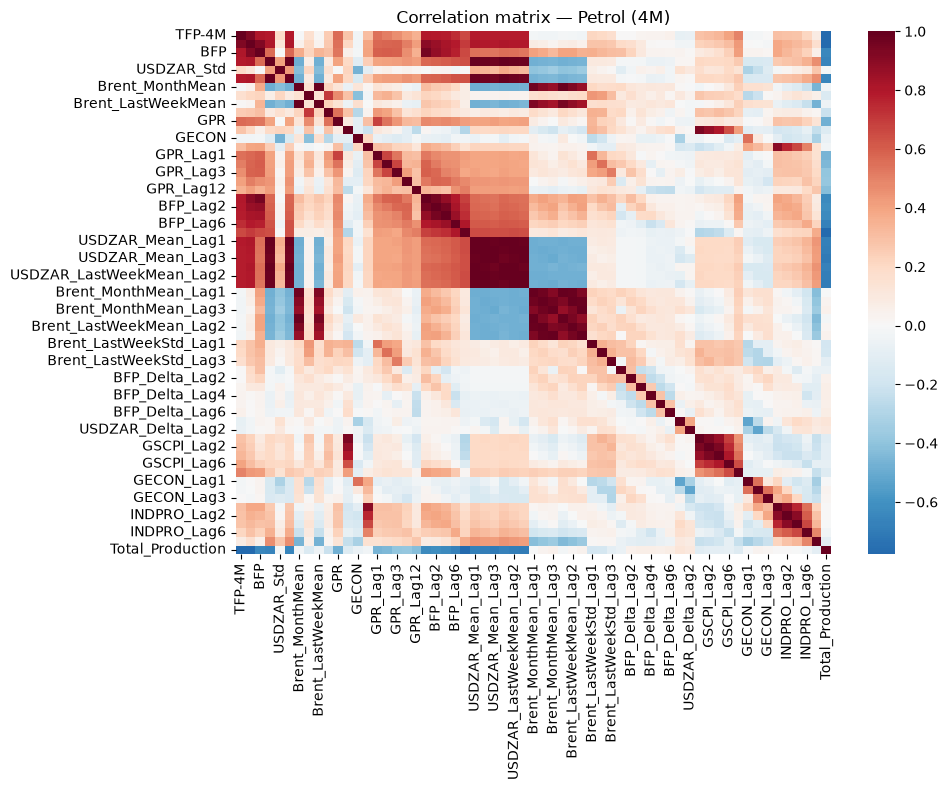

In [44]:
# --- Correlation heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(petrol_df_4M.corr(numeric_only=True), cmap="RdBu_r", center=0)
plt.title("Correlation matrix — Petrol (4M)")
plt.tight_layout()
plt.show()

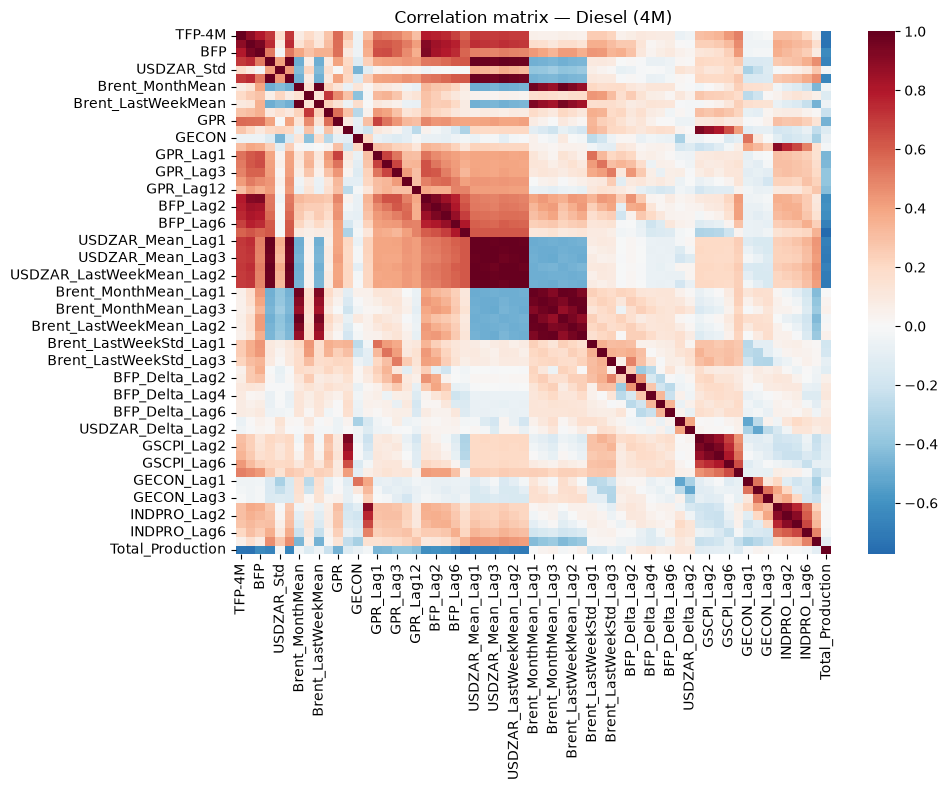

In [57]:
# --- Correlation heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(diesel_df_4M.corr(numeric_only=True), cmap="RdBu_r", center=0)
plt.title("Correlation matrix — Diesel (4M)")
plt.tight_layout()
plt.show()

## 5 Month Horizon

In [46]:
petrol_df_4M['TFP-5M'] = petrol_df_4M['Total_Fuel_Price'].shift(-5)
# Move 'TFP-2M' next to 'Date'
cols = ['Date', 'TFP-5M'] + [col for col in petrol_df_4M.columns if col not in ['Date', 'TFP-4M', 'TFP-5M']]
petrol_df_5M = petrol_df_4M[cols]

# Display the new dataframe
petrol_df_5M.head()

,Date,TFP-5M,Total_Fuel_Price,BFP,USDZAR_Mean,USDZAR_Std,USDZAR_LastWeekMean,Brent_MonthMean,Brent_MonthStd,Brent_LastWeekMean,...,GSCPI_Lag12,GECON_Lag1,GECON_Lag2,GECON_Lag3,INDPRO_Lag1,INDPRO_Lag2,INDPRO_Lag3,INDPRO_Lag6,INDPRO_Lag12,Total_Production
0,2011-01-01,1023.4,872.8,453.949,6.905624,0.159159,7.088029,96.523500,1.432121,96.987143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68537.7764
1,2011-02-01,992.4,898.8,479.949,7.140163,0.118266,7.115057,101.449655,4.976158,109.406667,...,NaN,0.247128,NaN,NaN,93.4814,NaN,NaN,NaN,NaN,68700.0099
2,2011-03-01,1009.4,941.8,522.949,6.967600,0.120730,6.867400,113.560000,3.168441,115.761429,...,NaN,0.423471,0.247128,NaN,93.1102,93.4814,NaN,NaN,NaN,67169.5421
3,2011-04-01,1018.4,996.4,552.149,6.805250,0.119489,6.745443,120.723704,4.066770,124.930000,...,NaN,-0.558572,0.423471,0.247128,94.0788,93.1102,93.4814,NaN,NaN,67351.0479
4,2011-05-01,1054.4,1025.4,581.149,6.828940,0.132094,6.962600,116.875000,5.568645,114.035000,...,NaN,-0.258231,-0.558572,0.423471,93.7749,94.0788,93.1102,NaN,NaN,67087.4645


In [47]:
diesel_df_4M['TFP-5M'] = diesel_df_4M['Total_Fuel_Price'].shift(-5)
# Move 'TFP-2M' next to 'Date'
cols = ['Date', 'TFP-5M'] + [col for col in diesel_df_4M.columns if col not in ['Date', 'TFP-4M', 'TFP-5M']]
diesel_df_5M = diesel_df_4M[cols]

# Display the new dataframe
diesel_df_5M.head()

,Date,TFP-5M,Total_Fuel_Price,BFP,USDZAR_Mean,USDZAR_Std,USDZAR_LastWeekMean,Brent_MonthMean,Brent_MonthStd,Brent_LastWeekMean,...,GSCPI_Lag12,GECON_Lag1,GECON_Lag2,GECON_Lag3,INDPRO_Lag1,INDPRO_Lag2,INDPRO_Lag3,INDPRO_Lag6,INDPRO_Lag12,Total_Production
0,2011-01-01,932.851,789.451,477.03,6.905624,0.159159,7.088029,96.523500,1.432121,96.987143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68537.7764
1,2011-02-01,920.851,821.451,509.03,7.140163,0.118266,7.115057,101.449655,4.976158,109.406667,...,NaN,0.247128,NaN,NaN,93.4814,NaN,NaN,NaN,NaN,68700.0099
2,2011-03-01,935.851,884.451,572.03,6.967600,0.120730,6.867400,113.560000,3.168441,115.761429,...,NaN,0.423471,0.247128,NaN,93.1102,93.4814,NaN,NaN,NaN,67169.5421
3,2011-04-01,935.851,953.851,616.03,6.805250,0.119489,6.745443,120.723704,4.066770,124.930000,...,NaN,-0.558572,0.423471,0.247128,94.0788,93.1102,93.4814,NaN,NaN,67351.0479
4,2011-05-01,972.851,969.851,632.03,6.828940,0.132094,6.962600,116.875000,5.568645,114.035000,...,NaN,-0.258231,-0.558572,0.423471,93.7749,94.0788,93.1102,NaN,NaN,67087.4645


In [64]:
corr_petrol = petrol_df_5M.corr(numeric_only=True)["TFP-5M"].sort_values(ascending=False)
corr_diesel = diesel_df_5M.corr(numeric_only=True)["TFP-5M"].sort_values(ascending=False)

print("\nHighest Correlations for Petrol (5M):")
print("=" * 40)
print(corr_petrol.head(10).to_string())
print("\nLowest Correlations for Petrol:")
print("=" * 40)
print(corr_petrol.tail(5).to_string())


Highest Correlations for Petrol (5M):
TFP-5M                      1.000000
TFP-6M                      0.983992
Total_Fuel_Price            0.928414
BFP                         0.792273
BFP_Lag1                    0.786299
USDZAR_Mean                 0.785253
USDZAR_Mean_Lag1            0.784359
USDZAR_LastWeekMean         0.783681
USDZAR_LastWeekMean_Lag1    0.782595
USDZAR_Mean_Lag2            0.782491

Lowest Correlations for Petrol:
Brent_MonthMean_Lag2   -0.036544
Brent_MonthMean_Lag3   -0.037490
USDZAR_Delta_Lag2      -0.054022
USDZAR_Delta_Lag1      -0.072372
Total_Production       -0.769629


In [65]:
print("\nHighest Correlations for Diesel (5M):")
print("=" * 40)
print(corr_diesel.head(10).to_string())
print("\nLowest Correlations for Diesel:")
print("=" * 40)
print(corr_diesel.tail(5).to_string())


Highest Correlations for Diesel (5M):
TFP-5M                 1.000000
TFP-6M                 0.971222
Total_Fuel_Price       0.883887
BFP                    0.790027
BFP_Lag1               0.773146
BFP_Lag2               0.751104
BFP_Lag3               0.724330
USDZAR_Mean            0.703711
USDZAR_LastWeekMean    0.702576
USDZAR_Mean_Lag1       0.701168

Lowest Correlations for Diesel:
GECON_Lag1          -0.025869
GECON               -0.042499
USDZAR_Delta_Lag2   -0.044873
USDZAR_Delta_Lag1   -0.045666
Total_Production    -0.721015


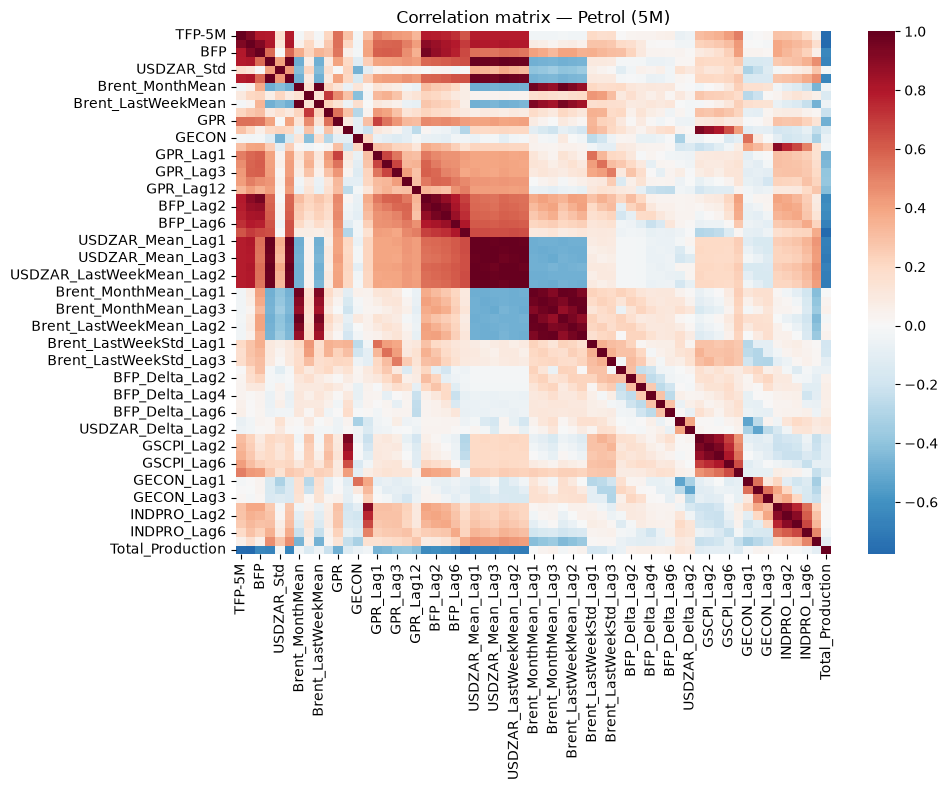

In [56]:
# --- Correlation heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(petrol_df_5M.corr(numeric_only=True), cmap="RdBu_r", center=0)
plt.title("Correlation matrix — Petrol (5M)")
plt.tight_layout()
plt.show()

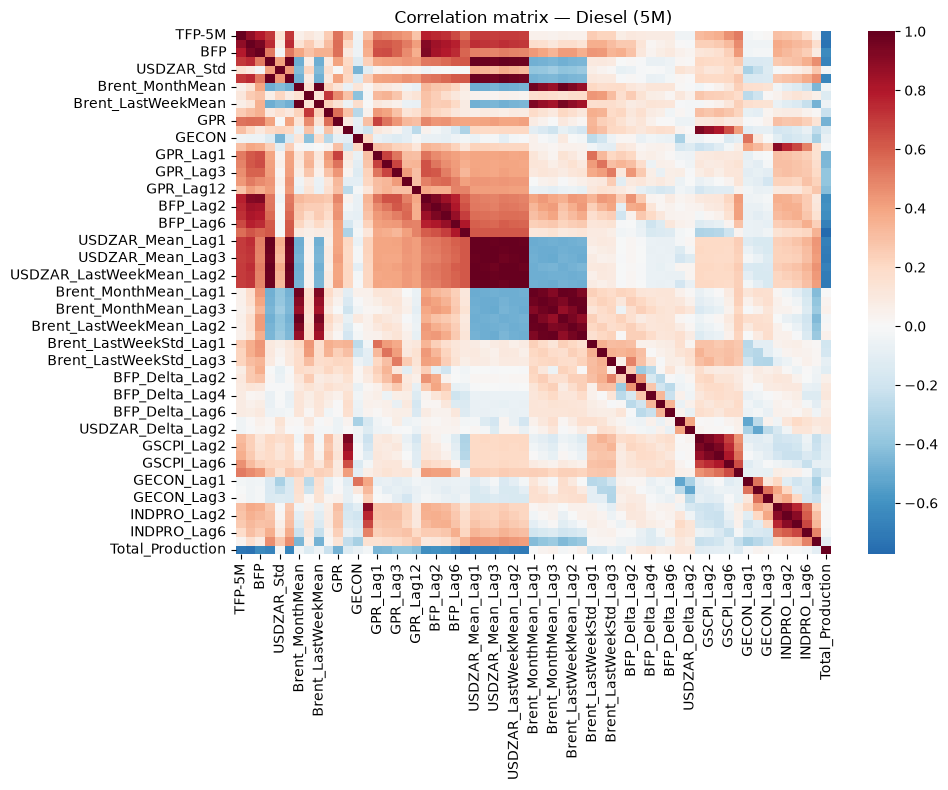

In [58]:
# --- Correlation heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(diesel_df_5M.corr(numeric_only=True), cmap="RdBu_r", center=0)
plt.title("Correlation matrix — Diesel (5M)")
plt.tight_layout()
plt.show()

## 6 Month Horizon

In [61]:
petrol_df_5M['TFP-6M'] = petrol_df_5M['Total_Fuel_Price'].shift(-6)
# Move 'TFP-2M' next to 'Date'
cols = ['Date', 'TFP-6M'] + [col for col in petrol_df_5M.columns if col not in ['Date', 'TFP-5M', 'TFP-6M']]
petrol_df_6M = petrol_df_5M[cols]

# Display the new dataframe
petrol_df_6M.head()

,Date,TFP-6M,Total_Fuel_Price,BFP,USDZAR_Mean,USDZAR_Std,USDZAR_LastWeekMean,Brent_MonthMean,Brent_MonthStd,Brent_LastWeekMean,...,GSCPI_Lag12,GECON_Lag1,GECON_Lag2,GECON_Lag3,INDPRO_Lag1,INDPRO_Lag2,INDPRO_Lag3,INDPRO_Lag6,INDPRO_Lag12,Total_Production
0,2011-01-01,992.4,872.8,453.949,6.905624,0.159159,7.088029,96.523500,1.432121,96.987143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68537.7764
1,2011-02-01,1009.4,898.8,479.949,7.140163,0.118266,7.115057,101.449655,4.976158,109.406667,...,NaN,0.247128,NaN,NaN,93.4814,NaN,NaN,NaN,NaN,68700.0099
2,2011-03-01,1018.4,941.8,522.949,6.967600,0.120730,6.867400,113.560000,3.168441,115.761429,...,NaN,0.423471,0.247128,NaN,93.1102,93.4814,NaN,NaN,NaN,67169.5421
3,2011-04-01,1054.4,996.4,552.149,6.805250,0.119489,6.745443,120.723704,4.066770,124.930000,...,NaN,-0.558572,0.423471,0.247128,94.0788,93.1102,93.4814,NaN,NaN,67351.0479
4,2011-05-01,1077.4,1025.4,581.149,6.828940,0.132094,6.962600,116.875000,5.568645,114.035000,...,NaN,-0.258231,-0.558572,0.423471,93.7749,94.0788,93.1102,NaN,NaN,67087.4645


In [62]:
diesel_df_5M['TFP-6M'] = diesel_df_5M['Total_Fuel_Price'].shift(-6)
# Move 'TFP-2M' next to 'Date'
cols = ['Date', 'TFP-6M'] + [col for col in diesel_df_5M.columns if col not in ['Date', 'TFP-5M', 'TFP-6M']]
diesel_df_6M = diesel_df_5M[cols]

# Display the new dataframe
diesel_df_6M.head()

,Date,TFP-6M,Total_Fuel_Price,BFP,USDZAR_Mean,USDZAR_Std,USDZAR_LastWeekMean,Brent_MonthMean,Brent_MonthStd,Brent_LastWeekMean,...,GSCPI_Lag12,GECON_Lag1,GECON_Lag2,GECON_Lag3,INDPRO_Lag1,INDPRO_Lag2,INDPRO_Lag3,INDPRO_Lag6,INDPRO_Lag12,Total_Production
0,2011-01-01,920.851,789.451,477.03,6.905624,0.159159,7.088029,96.523500,1.432121,96.987143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68537.7764
1,2011-02-01,935.851,821.451,509.03,7.140163,0.118266,7.115057,101.449655,4.976158,109.406667,...,NaN,0.247128,NaN,NaN,93.4814,NaN,NaN,NaN,NaN,68700.0099
2,2011-03-01,935.851,884.451,572.03,6.967600,0.120730,6.867400,113.560000,3.168441,115.761429,...,NaN,0.423471,0.247128,NaN,93.1102,93.4814,NaN,NaN,NaN,67169.5421
3,2011-04-01,972.851,953.851,616.03,6.805250,0.119489,6.745443,120.723704,4.066770,124.930000,...,NaN,-0.558572,0.423471,0.247128,94.0788,93.1102,93.4814,NaN,NaN,67351.0479
4,2011-05-01,1008.851,969.851,632.03,6.828940,0.132094,6.962600,116.875000,5.568645,114.035000,...,NaN,-0.258231,-0.558572,0.423471,93.7749,94.0788,93.1102,NaN,NaN,67087.4645


In [66]:
corr_petrol = petrol_df_6M.corr(numeric_only=True)["TFP-6M"].sort_values(ascending=False)
corr_diesel = diesel_df_6M.corr(numeric_only=True)["TFP-6M"].sort_values(ascending=False)

print("\nHighest Correlations for Petrol (6M):")
print("=" * 40)
print(corr_petrol.head(10).to_string())
print("\nLowest Correlations for Petrol:")
print("=" * 40)
print(corr_petrol.tail(5).to_string())


Highest Correlations for Petrol (6M):
TFP-6M                      1.000000
Total_Fuel_Price            0.924202
BFP                         0.786299
USDZAR_Mean                 0.784359
USDZAR_LastWeekMean         0.782595
USDZAR_Mean_Lag1            0.782491
USDZAR_LastWeekMean_Lag1    0.782018
BFP_Lag1                    0.779620
USDZAR_Mean_Lag2            0.779192
USDZAR_LastWeekMean_Lag2    0.779012

Lowest Correlations for Petrol:
Brent_MonthMean_Lag2   -0.037490
Brent_MonthMean_Lag3   -0.042690
USDZAR_Delta_Lag1      -0.054022
USDZAR_Delta_Lag2      -0.063326
Total_Production       -0.764081


In [67]:
print("\nHighest Correlations for Diesel (6M):")
print("=" * 40)
print(corr_diesel.head(10).to_string())
print("\nLowest Correlations for Diesel:")
print("=" * 40)
print(corr_diesel.tail(5).to_string())


Highest Correlations for Diesel (6M):
TFP-6M                      1.000000
Total_Fuel_Price            0.871952
BFP                         0.773146
BFP_Lag1                    0.751104
BFP_Lag2                    0.724330
USDZAR_Mean                 0.701168
USDZAR_LastWeekMean         0.700870
BFP_Lag3                    0.699784
USDZAR_LastWeekMean_Lag1    0.697398
USDZAR_Mean_Lag1            0.696696

Lowest Correlations for Diesel:
GECON_Lag1          -0.002693
GECON               -0.025869
USDZAR_Delta_Lag1   -0.044873
USDZAR_Delta_Lag2   -0.063593
Total_Production    -0.716826


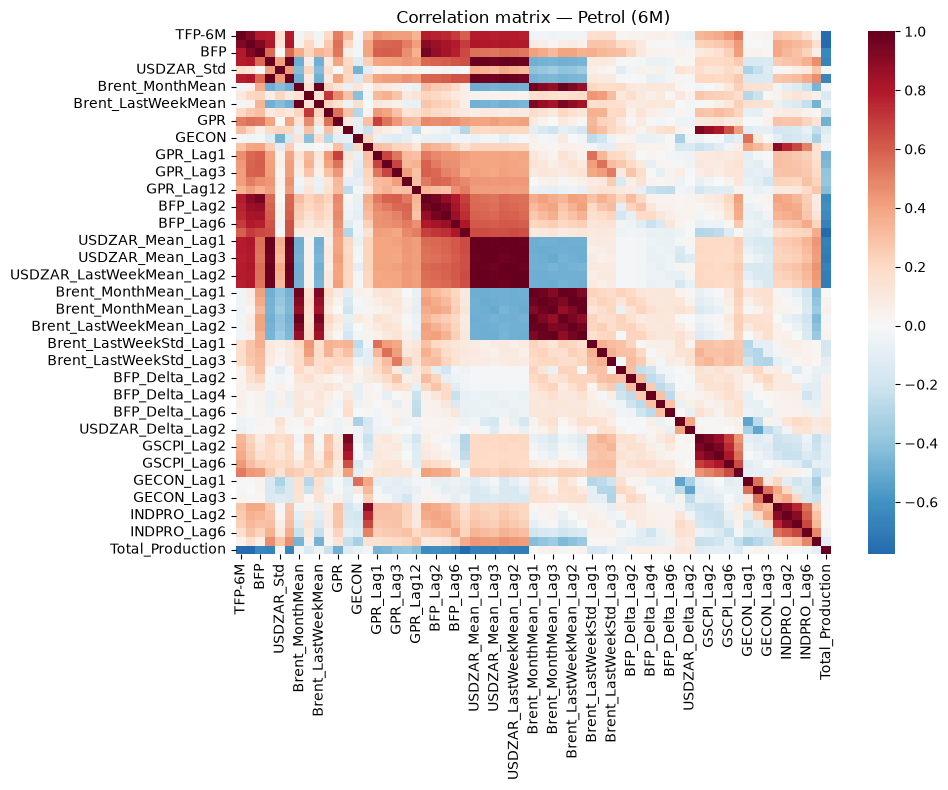

In [68]:
# --- Correlation heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(petrol_df_6M.corr(numeric_only=True), cmap="RdBu_r", center=0)
plt.title("Correlation matrix — Petrol (6M)")
plt.tight_layout()
plt.show()

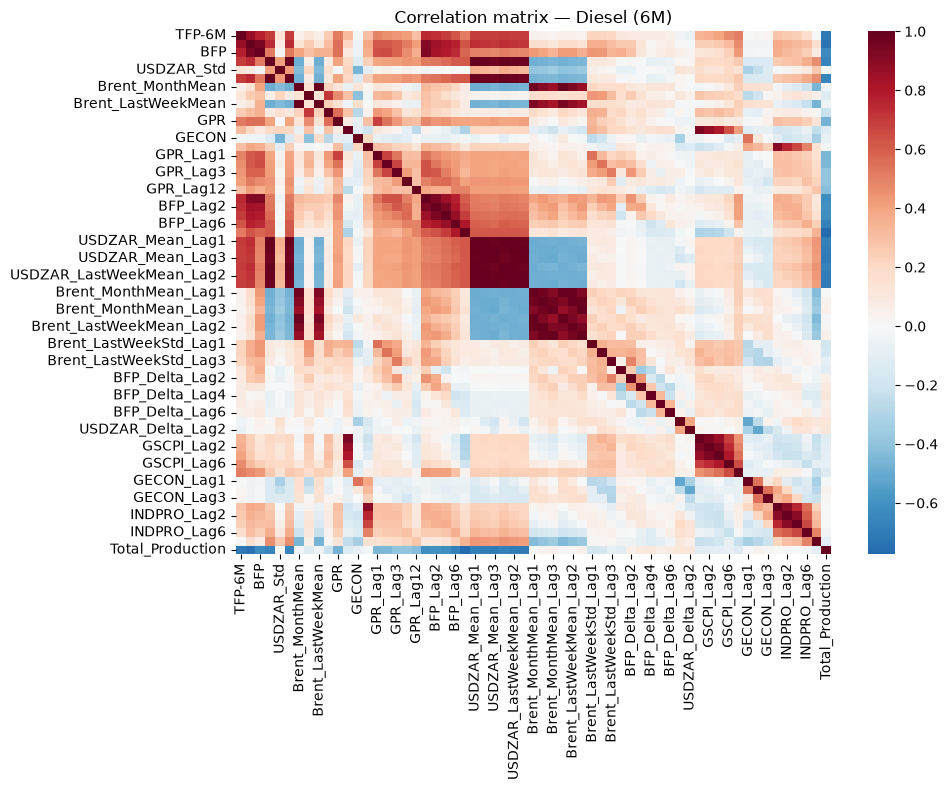

In [69]:
# --- Correlation heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(diesel_df_6M.corr(numeric_only=True), cmap="RdBu_r", center=0)
plt.title("Correlation matrix — Diesel (6M)")
plt.tight_layout()
plt.show()